# CNN-LSTM Autoencoder for Unsupervised Anomaly Detection

This notebook implements an unsupervised anomaly detection system for bridge sensor data using a CNN-LSTM autoencoder architecture.

**Approach:** Train the autoencoder on normal data only. During inference, anomalies produce higher reconstruction error because the model hasn't learned to reproduce anomalous patterns.

**Architecture Highlights:**
- Symmetric encoder-decoder with proper upsampling (no RepeatVector)
- BatchNorm and LayerNorm for training stability
- Dropout and recurrent dropout for regularization
- Gradient clipping and learning rate scheduling

## 1. Imports and Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [3]:
# Configuration
DATA_URL = "https://huggingface.co/datasets/Tchak91/ComplexBridges/resolve/main/ipmb_5sensors_30min_1_to_10hz.csv"
INPUT_WINDOW = 100  # 10 seconds of history at 10Hz
STRIDE = 10         # Window overlap (90% overlap)
BATCH_SIZE = 64
MAX_EPOCHS = 50

## 2. Load and Prepare Data

In [4]:
print("Loading data...")
df = pd.read_csv(DATA_URL)

# Parse timestamps with sub-second precision
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Loaded {len(df):,} rows")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Loading data...
Loaded 90,000 rows
Time range: 2025-10-10 12:00:00 to 2025-10-10 12:29:59.900000


,timestamp,bridge_id,span_id,sensor_id,sensor_type,value,unit,traffic_load_proxy,rule_threshold,anomaly,anomaly_type
0,2025-10-10 12:00:00,BRIDGE_A01,SPAN_1,SG_001,strain_gauge,118.571847,microstrain,0.5,200.00,0,NaN
1,2025-10-10 12:00:00,BRIDGE_A01,SPAN_2,SG_002,strain_gauge,128.986727,microstrain,0.5,200.00,0,NaN
2,2025-10-10 12:00:00,BRIDGE_A01,SPAN_1,ACC_101,accelerometer_rms,0.020849,g,0.5,0.05,0,NaN
3,2025-10-10 12:00:00,BRIDGE_A01,SPAN_2,ACC_102,accelerometer_rms,0.015481,g,0.5,0.05,0,NaN
4,2025-10-10 12:00:00,BRIDGE_A01,SPAN_2,TMP_201,temperature,21.884280,C,0.5,35.00,0,NaN


In [5]:
# Pivot to wide format: each sensor becomes a column
df['sensor_key'] = df['sensor_type'] + '_' + df['sensor_id']
pivot = df.pivot_table(index='timestamp', columns='sensor_key', values='value').ffill().bfill()

# Extract anomaly labels (1 if any sensor anomalous at that timestamp)
labels = df.pivot_table(
    index='timestamp', 
    columns='sensor_key', 
    values='anomaly', 
    aggfunc='max'
).max(axis=1)

print(f"Sensors: {pivot.columns.tolist()}")
print(f"Total timestamps: {len(pivot):,}")
print(f"Anomaly rate: {labels.mean():.2%}")

Sensors: ['accelerometer_rms_ACC_101', 'accelerometer_rms_ACC_102', 'strain_gauge_SG_001', 'strain_gauge_SG_002', 'temperature_TMP_201']
Total timestamps: 18,000
Anomaly rate: 21.39%


## 3. Train/Test Split

**Strategy:** Train only on normal data from the first 60% of the timeline. Test on everything else (including anomalies).

In [6]:
train_cutoff = int(len(pivot) * 0.60)

# Training: first 60%, normal data only
train_mask = (pivot.index < pivot.index[train_cutoff]) & (labels == 0)
X_train_raw = pivot[train_mask]

# Test: everything else
test_mask = ~train_mask
X_test_raw = pivot[test_mask]
y_test_labels = labels[test_mask]

print(f"Training samples: {len(X_train_raw):,} (all normal)")
print(f"Test samples: {len(X_test_raw):,} ({y_test_labels.mean():.2%} anomalous)")

Training samples: 9,995 (all normal)
Test samples: 8,005 (48.11% anomalous)


## 4. Preprocessing

Standardize features using statistics from normal training data only.

In [7]:
# Fit scaler on normal training data only
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

print(f"Train mean (should be ~0): {X_train_norm.mean():.4f}")
print(f"Train std (should be ~1): {X_train_norm.std():.4f}")

Train mean (should be ~0): 0.0000
Train std (should be ~1): 1.0000


In [8]:
def create_sequences(data, window_size, stride):
    """Create overlapping sequences for time-series modeling."""
    sequences = []
    for i in range(0, len(data) - window_size, stride):
        sequences.append(data[i : i + window_size])
    return np.array(sequences)

# Create sequences
X_train_seq = create_sequences(X_train_norm, INPUT_WINDOW, STRIDE)
X_test_seq = create_sequences(X_test_norm, INPUT_WINDOW, STRIDE)

print(f"Training sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

Training sequences: (990, 100, 5)
Test sequences: (791, 100, 5)


In [9]:
# Create sequence-level labels for test set
# A sequence is anomalous if ANY point in the window is anomalous
y_test_seq_labels = []
labels_array = y_test_labels.values

for i in range(0, len(X_test_norm) - INPUT_WINDOW, STRIDE):
    window_labels = labels_array[i : i + INPUT_WINDOW]
    y_test_seq_labels.append(1 if window_labels.sum() > 0 else 0)

y_test_seq_labels = np.array(y_test_seq_labels)
print(f"Test sequence anomaly rate: {y_test_seq_labels.mean():.2%}")

Test sequence anomaly rate: 50.70%


## 5. Model Architecture

**CNN-LSTM Autoencoder** with symmetric encoder-decoder:

```
Encoder: Input(100,5) → Conv1D → Pool(50) → Conv1D → Pool(25) → LSTM → LSTM → Latent(32)
Decoder: Latent(32) → Dense → Reshape(25,32) → LSTM → Upsample(50) → Conv1D → Upsample(100) → Output(100,5)
```

**Stability features:**
- BatchNormalization after Conv layers
- LayerNormalization before LSTM layers  
- Dropout (0.2) and recurrent dropout (0.1)
- Gradient clipping (clipnorm=1.0)

In [10]:
n_features = X_train_seq.shape[2]

# Input
inputs = layers.Input(shape=(INPUT_WINDOW, n_features))

# --- ENCODER ---
# CNN block 1: extract local patterns
x = layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.MaxPooling1D(pool_size=2)(x)  # 100 -> 50

# CNN block 2: higher-level features
x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.MaxPooling1D(pool_size=2)(x)  # 50 -> 25

# LSTM encoder
x = layers.LayerNormalization()(x)
x = layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)(x)
x = layers.LayerNormalization()(x)
encoded = layers.LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.1)(x)

# --- DECODER ---
# Project latent to sequence shape
x = layers.Dense(25 * 32, activation='relu')(encoded)
x = layers.Reshape((25, 32))(x)

# LSTM decoder
x = layers.LayerNormalization()(x)
x = layers.LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)(x)

# Upsample back to original length
x = layers.UpSampling1D(size=2)(x)  # 25 -> 50
x = layers.Conv1D(32, kernel_size=5, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)

x = layers.UpSampling1D(size=2)(x)  # 50 -> 100
outputs = layers.Conv1D(n_features, kernel_size=7, padding="same")(x)

# Build model
model = models.Model(inputs, outputs, name="CNN_LSTM_Autoencoder")

In [11]:
# Compile with gradient clipping
optimizer = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='mse')

model.summary()

Model: "CNN_LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 100, 32)        │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 50, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 25, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 25, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 25, 64)         │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 800)            │        26,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 25, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 25, 32)         │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 25, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 50, 32)         │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 50, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_3 (UpSampling1D)  │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 100, 5)         │         1,12

 Total params: 120,357 (470.14 KB)

 Trainable params: 120,101 (469.14 KB)

 Non-trainable params: 256 (1.00 KB)

## 6. Training

**Callbacks:**
- `EarlyStopping`: Stop when validation loss stops improving (patience=15)
- `ReduceLROnPlateau`: Halve learning rate when stuck (patience=5)

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

In [13]:
# Train: input = target (reconstruction task)
history = model.fit(
    X_train_seq, X_train_seq,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 287ms/step - loss: 1.5646 - val_loss: 1.9926 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - loss: 0.6264 - val_loss: 1.8392 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - loss: 0.5355 - val_loss: 1.6502 - learning_rate: 0.0010
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - loss: 0.5051 - val_loss: 1.5256 - learning_rate: 0.0010
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - loss: 0.4956 - val_loss: 1.4485 - learning_rate: 0.0010
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - loss: 0.4764 - val_loss: 1.3685 - learning_rate: 0.0010
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.4688 - val_loss: 1.2796 - learning_rate: 0.0010
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - loss: 0.4689 - val_loss: 1.2081 - learning_rate: 0.0010
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - loss: 0.4540 - val_loss: 1.1635 - learning_rate: 0.0010
Epoch 10/

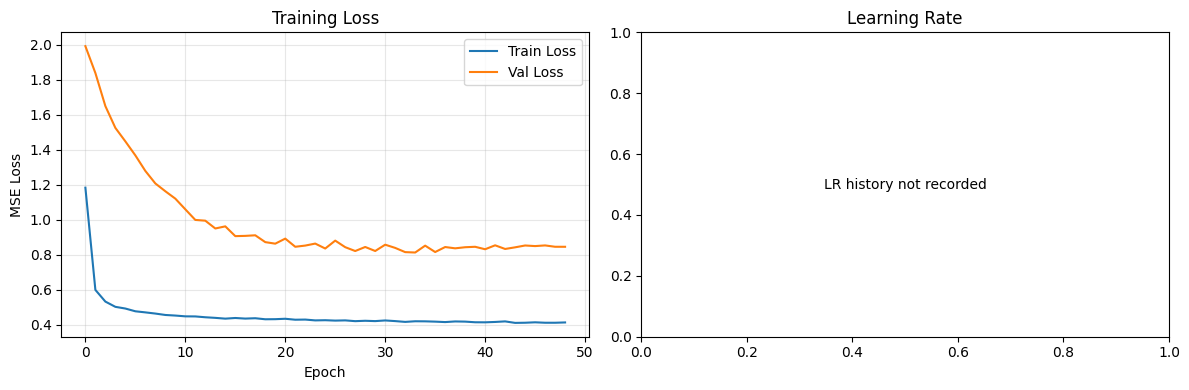

In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if 'lr' in history.history:
    axes[1].plot(history.history['lr'])
    axes[1].set_title('Learning Rate Schedule')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Learning Rate')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'LR history not recorded', ha='center', va='center')
    axes[1].set_title('Learning Rate')

plt.tight_layout()
plt.show()

## 7. Anomaly Detection via Reconstruction Error

The **reconstruction error** (MAE between input and output) serves as our anomaly score:
- **Low error** → Pattern is similar to training data (normal)
- **High error** → Pattern is unfamiliar (potentially anomalous)

We set the threshold at the **99th percentile** of training reconstruction error.

In [15]:
# Get reconstructions
X_test_pred = model.predict(X_test_seq, verbose=0)
X_train_pred = model.predict(X_train_seq, verbose=0)

# Calculate reconstruction error (MAE per sequence)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test_seq), axis=(1, 2))
train_mae_loss = np.mean(np.abs(X_train_pred - X_train_seq), axis=(1, 2))

# Set threshold at 99th percentile of training error
threshold = np.percentile(train_mae_loss, 99)

print(f"Training MAE - Mean: {train_mae_loss.mean():.4f}, Std: {train_mae_loss.std():.4f}")
print(f"Threshold (99th percentile): {threshold:.4f}")

Training MAE - Mean: 0.4829, Std: 0.0781
Threshold (99th percentile): 0.8016


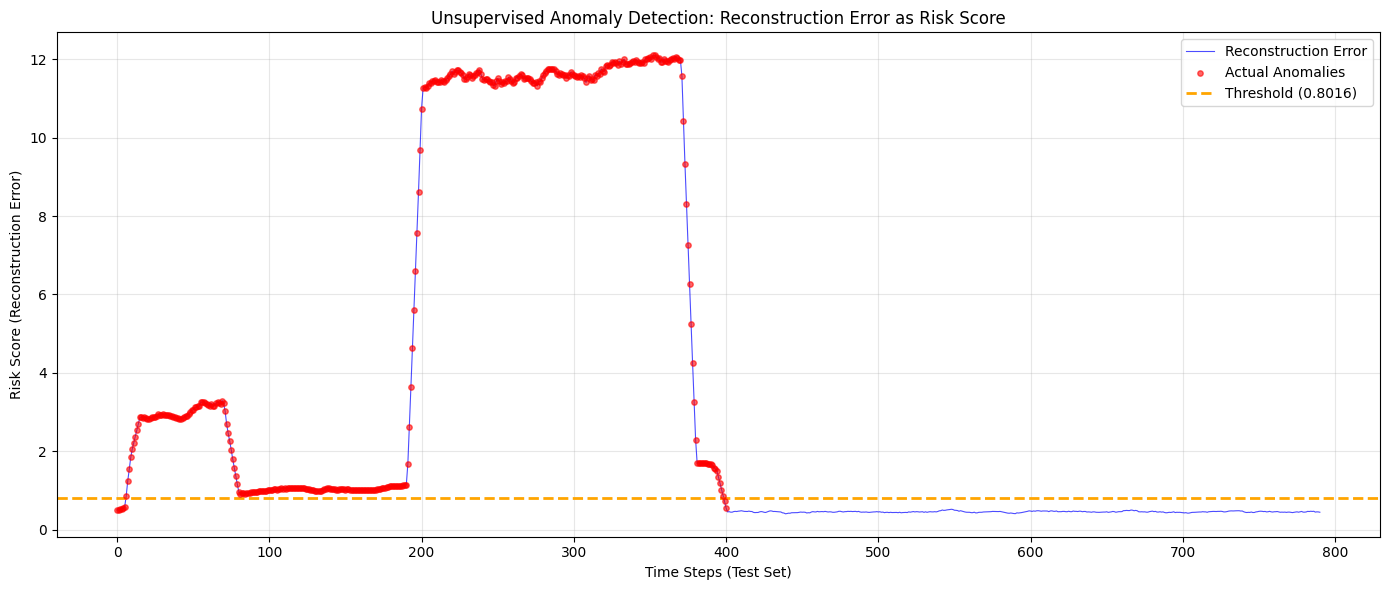

In [16]:
# Visualize reconstruction error over time
plt.figure(figsize=(14, 6))

plt.plot(test_mae_loss, label='Reconstruction Error', color='blue', alpha=0.7, linewidth=0.8)

# Highlight actual anomalies
anomaly_indices = np.where(y_test_seq_labels == 1)[0]
plt.scatter(anomaly_indices, test_mae_loss[anomaly_indices], 
            color='red', s=15, alpha=0.6, label='Actual Anomalies', zorder=5)

plt.axhline(threshold, color='orange', linestyle='--', linewidth=2, 
            label=f'Threshold ({threshold:.4f})')

plt.title('Unsupervised Anomaly Detection: Reconstruction Error as Risk Score')
plt.xlabel('Time Steps (Test Set)')
plt.ylabel('Risk Score (Reconstruction Error)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Per-Sensor Error Analysis

Breaking down reconstruction error by sensor helps **localize** which sensors are behaving anomalously.

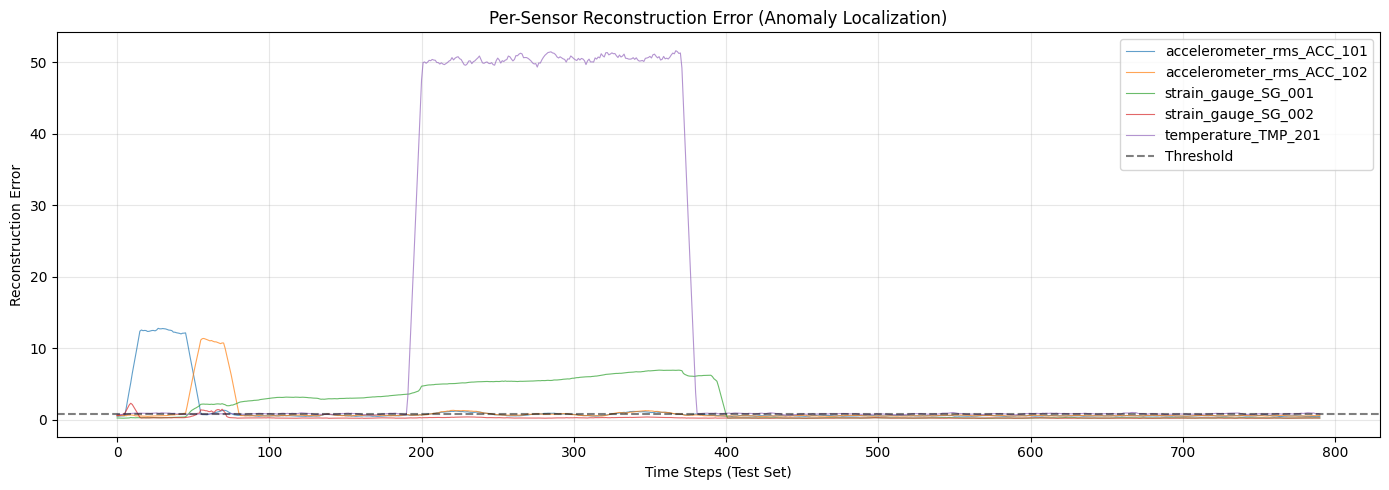

In [17]:
# Per-sensor reconstruction error
per_sensor_mae = np.mean(np.abs(X_test_pred - X_test_seq), axis=1)  # (n_samples, n_features)

sensor_names = pivot.columns.tolist()

plt.figure(figsize=(14, 5))
for i, name in enumerate(sensor_names):
    plt.plot(per_sensor_mae[:, i], label=name, alpha=0.7, linewidth=0.8)

plt.axhline(threshold, color='black', linestyle='--', alpha=0.5, label='Threshold')
plt.legend(loc='upper right')
plt.title('Per-Sensor Reconstruction Error (Anomaly Localization)')
plt.xlabel('Time Steps (Test Set)')
plt.ylabel('Reconstruction Error')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

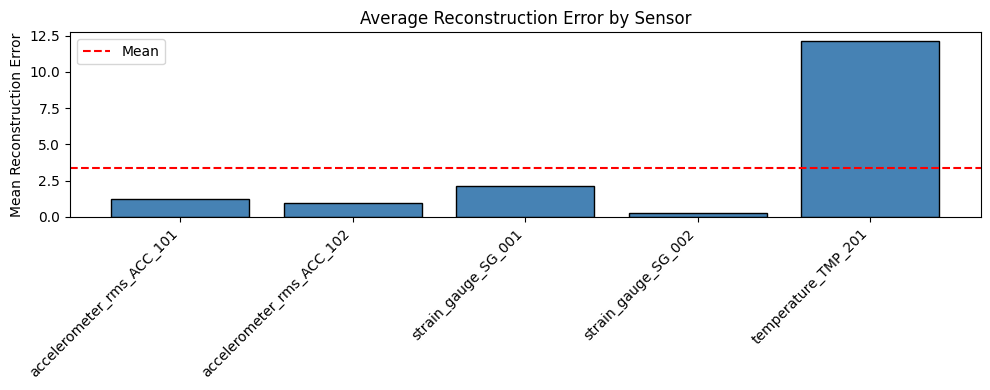

In [18]:
# Average error contribution by sensor
avg_sensor_error = per_sensor_mae.mean(axis=0)

plt.figure(figsize=(10, 4))
bars = plt.bar(sensor_names, avg_sensor_error, color='steelblue', edgecolor='black')
plt.axhline(avg_sensor_error.mean(), color='red', linestyle='--', label='Mean')
plt.title('Average Reconstruction Error by Sensor')
plt.ylabel('Mean Reconstruction Error')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Performance Metrics

In [19]:
# Convert reconstruction error to binary predictions
preds = (test_mae_loss > threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test_seq_labels, preds))
print("\nClassification Report:")
print(classification_report(y_test_seq_labels, preds, target_names=['Normal', 'Anomaly']))

Confusion Matrix:
[[390   0]
 [  8 393]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       390
     Anomaly       1.00      0.98      0.99       401

    accuracy                           0.99       791
   macro avg       0.99      0.99      0.99       791
weighted avg       0.99      0.99      0.99       791



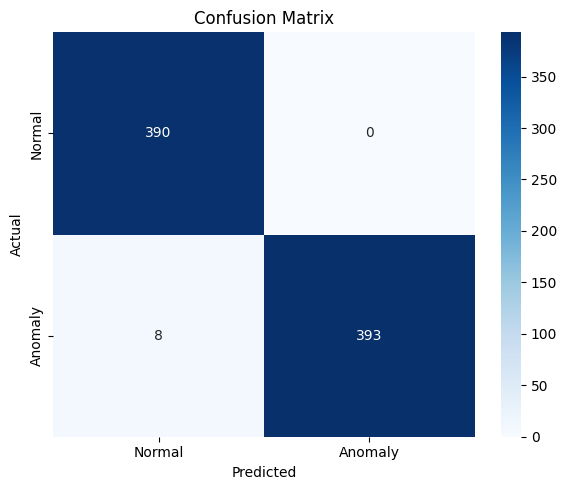

In [20]:
# Visualize confusion matrix
cm = confusion_matrix(y_test_seq_labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 10. Summary

**What the reconstruction error tells us:**
- The model learns to compress and reconstruct "normal" sensor patterns
- High reconstruction error indicates patterns the model hasn't seen during training
- This could be: true anomalies, novel operating conditions, or sensor drift

**Next steps to improve:**
- Add STFT frequency-domain features (see Hell Bridge implementation)
- Include temperature conditioning for environmental compensation
- Apply temporal smoothing (rolling mean) to reduce false positives
- Tune threshold based on operational requirements (precision vs recall tradeoff)